In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thêm đường dẫn để nhận diện module từ src
root = os.path.abspath(os.path.join(".."))
if root not in sys.path:
    sys.path.append(root)

from src.data.loader import load_raw_data
from sklearn.preprocessing import StandardScaler

# 2. Nạp dữ liệu gốc
df = load_raw_data()

✅ Đã nạp dữ liệu: (284807, 31)


In [2]:
# Kiểm tra số dòng trùng
duplicate_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicate_count}")

# Loại bỏ trùng lặp để tránh làm mô hình bị "overfit"
df_clean = df.drop_duplicates()
print(f"Kích thước sau khi làm sạch: {df_clean.shape}")

Số dòng trùng lặp: 1081
Kích thước sau khi làm sạch: (283726, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_9576\2713060924.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['std_amount'] = scaler.fit_transform(df_clean['Amount'].values.reshape(-1, 1))


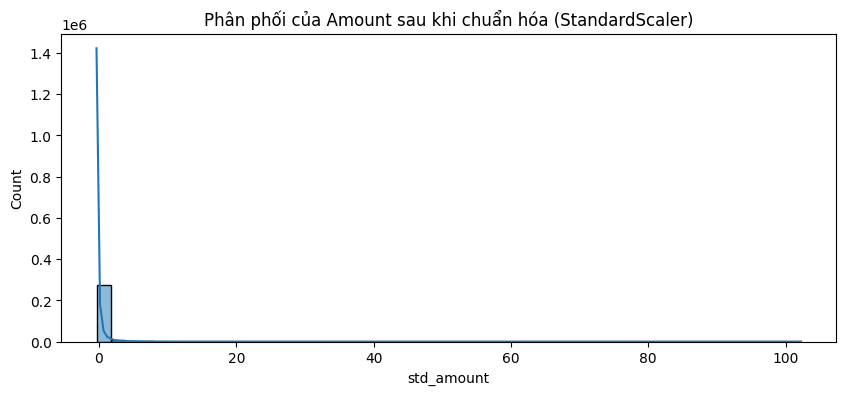

In [3]:
# Sử dụng StandardScaler để đưa Amount về cùng thang đo với các biến V
scaler = StandardScaler()

df_clean['std_amount'] = scaler.fit_transform(df_clean['Amount'].values.reshape(-1, 1))

# Loại bỏ các cột không cần thiết (Time và Amount cũ)
df_final = df_clean.drop(['Time', 'Amount'], axis=1)

# Trực quan hóa kết quả sau khi chuẩn hóa
plt.figure(figsize=(10, 4))
sns.histplot(df_final['std_amount'], bins=50, kde=True)
plt.title("Phân phối của Amount sau khi chuẩn hóa (StandardScaler)")
plt.show()

In [4]:
processed_path = "../data/processed/creditcard_cleaned.csv"

# Tạo thư mục nếu chưa có
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

df_final.to_csv(processed_path, index=False)
print("✅ Đã lưu dữ liệu sạch vào data/processed/!")

✅ Đã lưu dữ liệu sạch vào data/processed/!
